# Conhecendo a base de dados

## Importando os dados!


In [1]:
import pandas as pd

In [2]:
dados = 'https://raw.githubusercontent.com/alura-cursos/pandas-conhecendo-a-biblioteca/main/base-de-dados/aluguel.csv'

In [3]:
df_aluguel = pd.read_csv(dados, sep=';')
df_aluguel

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
...,...,...,...,...,...,...,...,...,...
32955,Quitinete,Centro,0,0,0,27,800.0,350.0,25.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0
32958,Apartamento,Leblon,2,0,0,70,3000.0,760.0,NaN


## Características gerais da base de dados

In [4]:
df_aluguel.shape

(32960, 9)

In [5]:
df_aluguel.columns

Index(['Tipo', 'Bairro', 'Quartos', 'Vagas', 'Suites', 'Area', 'Valor',
       'Condominio', 'IPTU'],
      dtype='str')

In [6]:
df_aluguel.info()

<class 'pandas.DataFrame'>
RangeIndex: 32960 entries, 0 to 32959
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        32960 non-null  str    
 1   Bairro      32960 non-null  str    
 2   Quartos     32960 non-null  int64  
 3   Vagas       32960 non-null  int64  
 4   Suites      32960 non-null  int64  
 5   Area        32960 non-null  int64  
 6   Valor       32943 non-null  float64
 7   Condominio  28867 non-null  float64
 8   IPTU        22723 non-null  float64
dtypes: float64(3), int64(4), str(2)
memory usage: 2.3 MB


In [7]:
df_aluguel['Tipo'].value_counts()

Tipo
Apartamento                    19532
Conjunto Comercial/Sala         6815
Loja/Salão                      1426
Casa de Condomínio               996
Casa                             967
Quitinete                        836
Galpão/Depósito/Armazém          623
Flat                             476
Prédio Inteiro                   301
Casa Comercial                   265
Casa de Vila                     249
Loja Shopping/ Ct Comercial      247
Box/Garagem                       82
Terreno Padrão                    70
Loft                              51
Sítio                             10
Loteamento/Condomínio              5
Studio                             4
Hotel                              2
Chácara                            1
Pousada/Chalé                      1
Indústria                          1
Name: count, dtype: int64

In [8]:
df_aluguel.head(7)
df_aluguel.tail(5)
df_aluguel.info()

<class 'pandas.DataFrame'>
RangeIndex: 32960 entries, 0 to 32959
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        32960 non-null  str    
 1   Bairro      32960 non-null  str    
 2   Quartos     32960 non-null  int64  
 3   Vagas       32960 non-null  int64  
 4   Suites      32960 non-null  int64  
 5   Area        32960 non-null  int64  
 6   Valor       32943 non-null  float64
 7   Condominio  28867 non-null  float64
 8   IPTU        22723 non-null  float64
dtypes: float64(3), int64(4), str(2)
memory usage: 2.3 MB


# Análise exploratória de dados

## Qual o valor médio de aluguel por tipo de imóvel?

In [17]:
import matplotlib as plt

<Axes: title={'center': 'Valor médio por tipo de imóvel'}, xlabel='Valor médio', ylabel='Tipo de imóvel'>

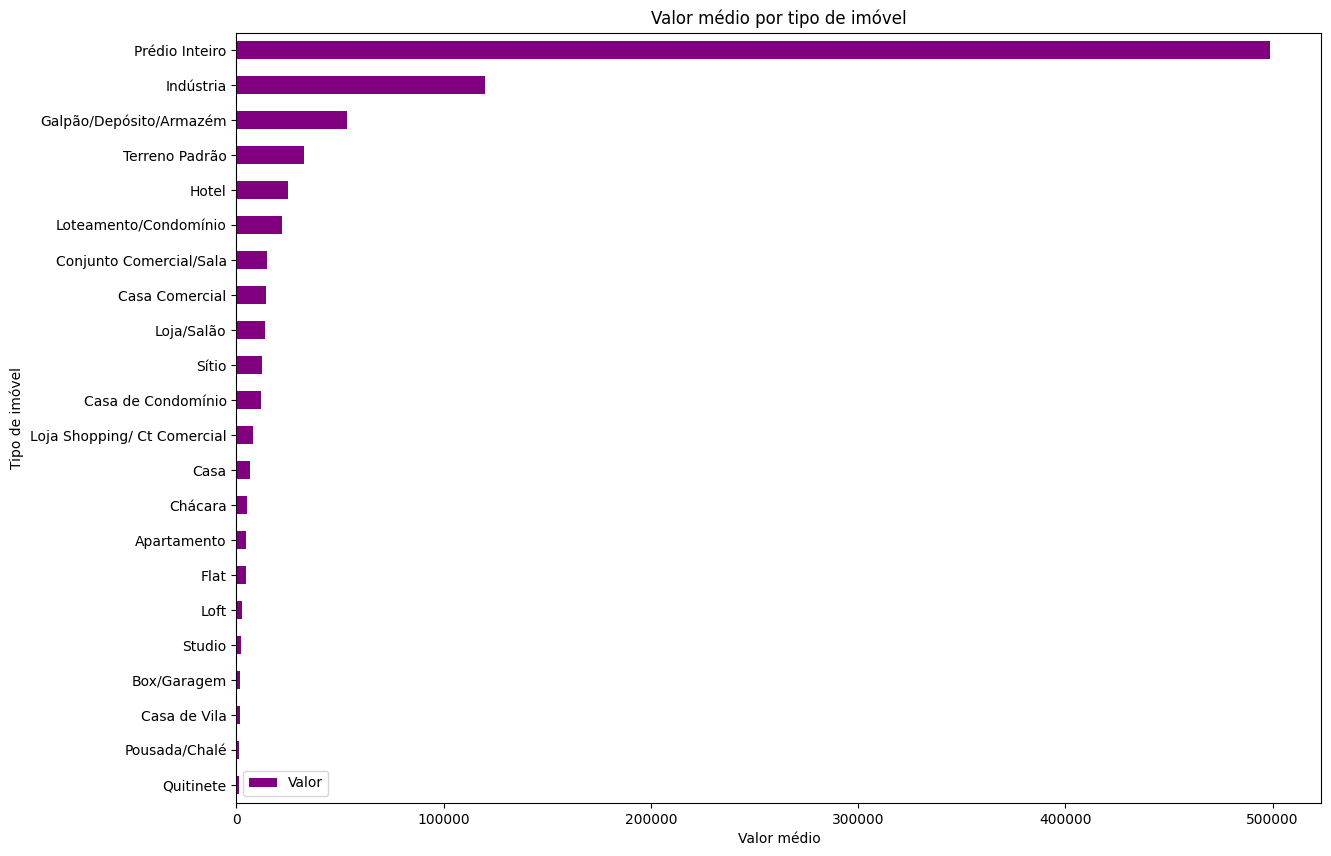

In [18]:
df_preçotipo = df_aluguel.groupby('Tipo')[['Valor']].mean().sort_values('Valor')
df_preçotipo.plot.barh(title='Valor médio por tipo de imóvel', xlabel='Valor médio', ylabel='Tipo de imóvel', color='purple', figsize=(14, 10))

## Removendo os imóveis comerciais

In [19]:
df_aluguel.Tipo.unique()

<StringArray>
[                  'Quitinete',                        'Casa',
     'Conjunto Comercial/Sala',                 'Apartamento',
          'Casa de Condomínio',              'Prédio Inteiro',
                        'Flat',                  'Loja/Salão',
     'Galpão/Depósito/Armazém',              'Casa Comercial',
                'Casa de Vila',              'Terreno Padrão',
                 'Box/Garagem',                        'Loft',
 'Loja Shopping/ Ct Comercial',                     'Chácara',
       'Loteamento/Condomínio',                       'Sítio',
               'Pousada/Chalé',                      'Studio',
                       'Hotel',                   'Indústria']
Length: 22, dtype: str

In [20]:
imoveis_comerciais = ['Conjunto Comercial/Sala', 
                      'Prédio Inteiro', 'Loja/Salão', 
                      'Galpão/Depósito/Armazém', 
                      'Casa Comercial', 'Terreno Padrão',
                      'Loja Shopping/ Ct Comercial',
                      'Box/Garagem', 'Chácara',
                      'Loteamento/Condomínio', 'Sítio',
                      'Pousada/Chalé', 'Hotel', 'Indústria']
                                            


In [21]:
dados = df_aluguel

In [25]:
df = dados.query('not Tipo in @imoveis_comerciais')
df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN


In [26]:
df.Tipo.unique()

<StringArray>
[         'Quitinete',               'Casa',        'Apartamento',
 'Casa de Condomínio',               'Flat',       'Casa de Vila',
               'Loft',             'Studio']
Length: 8, dtype: str

<Axes: title={'center': 'Valor médio por tipo de imóvel'}, xlabel='Valor médio', ylabel='Tipo de imóvel'>

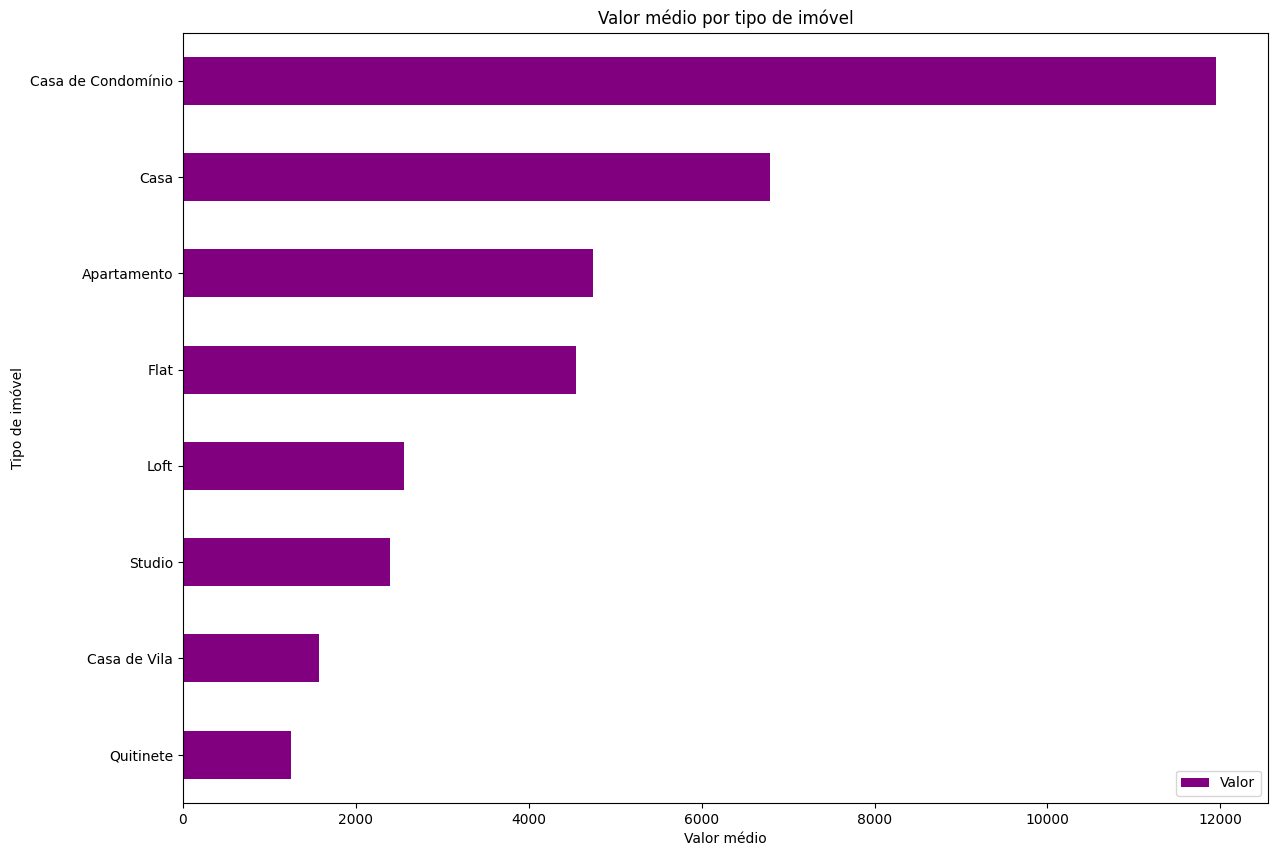

In [27]:
df_preçotipo = df.groupby('Tipo')[['Valor']].mean().sort_values('Valor')
df_preçotipo.plot.barh(title='Valor médio por tipo de imóvel', xlabel='Valor médio', ylabel='Tipo de imóvel', color='purple', figsize=(14, 10))

In [29]:
dados.query('Quartos >= 1')

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
32952,Casa de Condomínio,Barra da Tijuca,5,3,4,450,15000.0,1711.0,2332.0
32953,Apartamento,Méier,2,0,0,70,900.0,490.0,48.0
32956,Apartamento,Jacarepaguá,3,1,2,78,1800.0,800.0,40.0
32957,Apartamento,São Francisco Xavier,2,1,0,48,1400.0,509.0,37.0


## Qual o percentual de cada tipo de imóvel na nossa base de dados?

<Axes: title={'center': 'Proporção de tipos de imóveis'}, xlabel='Proporção', ylabel='Tipo de imóvel'>

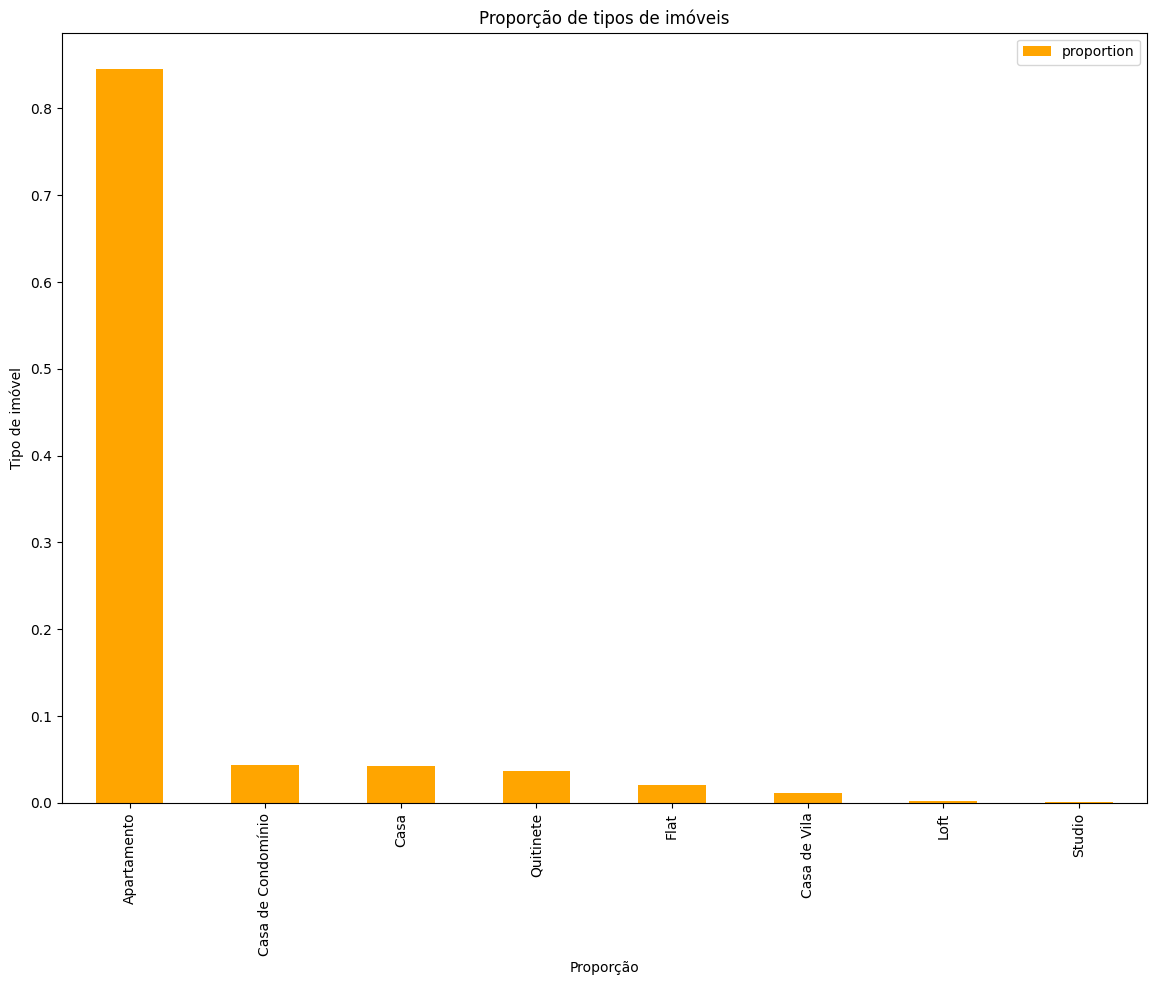

In [44]:
df.Tipo.value_counts(normalize=True).to_frame().plot(kind='bar',title='Proporção de tipos de imóveis', xlabel='Proporção', ylabel='Tipo de imóvel', color='orange', figsize=(14, 10))

### **Selecionando apenas os imóveis do tipo apartamento**

In [47]:
df = df.query('Tipo == "Apartamento"')
df.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN
5,Apartamento,Vista Alegre,3,1,0,70,1200.0,NaN,NaN
6,Apartamento,Cachambi,2,0,0,50,1300.0,301.0,17.0
10,Apartamento,Centro,1,0,0,36,1200.0,NaN,NaN


# Tratando e filtrando os dados

## Lidando com dados nulos

## Removendo registros

## Filtros

### **1. Apartamentos que possuem `1 quarto` e `aluguel menor que 1200`**



### **2. `Apartamentos` que possuem pelo menos `2 quartos`, `aluguel menor que 3000` e `area maior que 70`**

## Salvando os dados

# Manipulando os dados

## Criando colunas numéricas

## Criando colunas categóricas